In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_dots_multiple_percentiles(file_dists='dists.csv', 
                                   file_R0='R0.csv', 
                                   file_sigma='sigma.csv',
                                   percentiles=[100, 80, 60, 40, 20, 10],
                                   true_R0=None,
                                   true_sigma=None,
                                   title="R0 vs sigma - Multiple Percentiles",
                                   save_path='../../experimental_data/from_260312/'):
    """
    Create 6 subplots showing R0 vs sigma for different distance percentiles.
    
    Parameters:
    -----------
    file_dists : str
        CSV file with distances (single column)
    file_R0 : str
        CSV file with R0 samples
    file_sigma : str
        CSV file with sigma samples
    percentiles : list
        List of percentiles to plot [100, 80, 60, 40, 20, 10]
    true_R0 : float, optional
        True R0 value to mark on plots
    true_sigma : float, optional
        True sigma value to mark on plots
    title : str
        Overall figure title
    save_path : str
        Directory to save figure
    """
    # Load data
    distances = pd.read_csv(file_dists, header=None).values.ravel()
    data_R0 = pd.read_csv(file_R0, header=None).values.ravel()
    data_sigma = pd.read_csv(file_sigma, header=None).values.ravel()
    
    print(f"Loaded {len(distances)} samples")
    
    # Create figure with 6 subplots (2 rows x 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()  # Flatten to 1D array for easy indexing
    
    # Plot for each percentile
    for idx, percentile in enumerate(percentiles):
        ax = axes[idx]
        
        # Calculate threshold
        if percentile == 100:
            # Keep all samples
            selected_indices = np.arange(len(distances))
        else:
            threshold = np.percentile(distances, percentile)
            selected_indices = np.where(distances <= threshold)[0]
        
        n_selected = len(selected_indices)
        print("selected:", n_selected, percentile)
        
        # Select corresponding samples
        selected_R0 = data_R0[selected_indices]
        selected_sigma = data_sigma[selected_indices]
        
        # Scatter plot
        ax.scatter(selected_R0, selected_sigma, alpha=0.5, s=20, c='blue')
        
        # Mark true values if provided
        if true_R0 is not None and true_sigma is not None:
            ax.scatter(true_R0, true_sigma, s=200, c='red', marker='*',
                      edgecolors='black', linewidths=2, label='True value', zorder=5)
            ax.legend(loc='best')
        
        # Labels and title
        ax.set_xlabel('R0', fontsize=11)
        ax.set_ylabel('sigma', fontsize=11)
        ax.set_title(f'{percentile}th percentile\n({n_selected} samples, {n_selected/len(distances)*100:.1f}%)',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Overall title
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    save_file = f"{save_path}{title.replace(' ', '_').replace('-', '')}.png"
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_file}")
    plt.close()



In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_dots_from_two_files(
    file_ss='ss.csv',
    file_R0='R0.csv',
    title='Scatter Plot',
    save_dir='.'
):
    """
    Plot scatter points using:
    - x = 1st column of file_R0
    - y = 3rd column of file_ss

    Parameters
    ----------
    file_ss : str
        Path to CSV file ss
    file_R0 : str
        Path to CSV file R0
    title : str
        Figure title
    save_dir : str
        Directory to save the figure
    """
    # Load CSV files
    data_ss = pd.read_csv(file_ss, header=None)
    data_R0 = pd.read_csv(file_R0, header=None)

    print(f"Loaded A shape: {data_ss.shape}")
    print(f"Loaded B shape: {data_R0.shape}")

    # Check column counts
    if data_ss.shape[1] < 3:
        raise ValueError(f"file_ss must have at least 3 columns, but got {data_ss.shape[1]}")
    if data_R0.shape[1] < 1:
        raise ValueError(f"file_R0 must have at least 1 column, but got {data_R0.shape[1]}")

    # Check row counts
    if len(data_ss) != len(data_R0):
        raise ValueError(
            f"file_ss and file_R0 must have the same number of rows, "
            f"but got {len(data_ss)} and {len(data_R0)}"
        )

    # Extract columns
    x = data_R0.iloc[:, 0]
    y = data_ss.iloc[:, 2]

    # Make save directory if needed
    os.makedirs(save_dir, exist_ok=True)

    # Safe filename
    filename = title.replace(" ", "_") + ".png"
    save_path = os.path.join(save_dir, filename)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y)
    plt.xlabel("R0")
    plt.ylabel("npmi")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figure saved to: {save_path}")

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


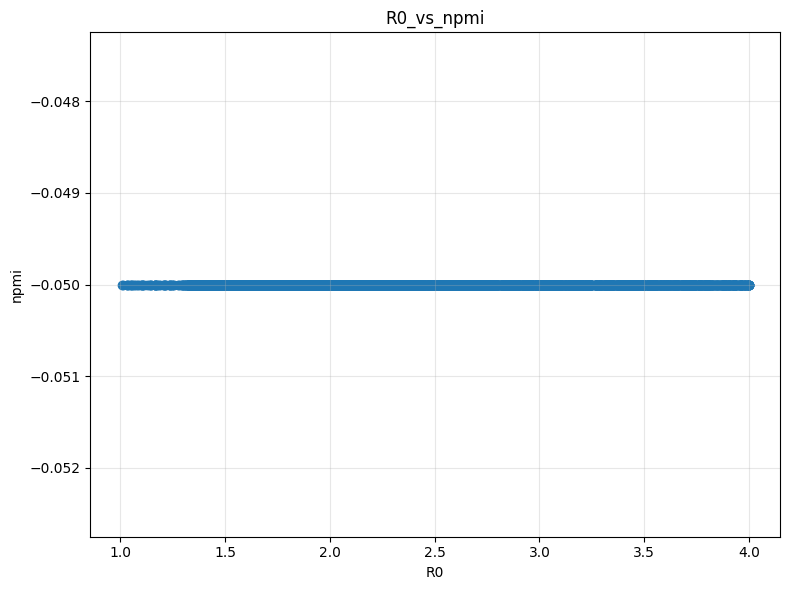

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_npmi.png


In [3]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    title='R0_vs_npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R02p5/'
)

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


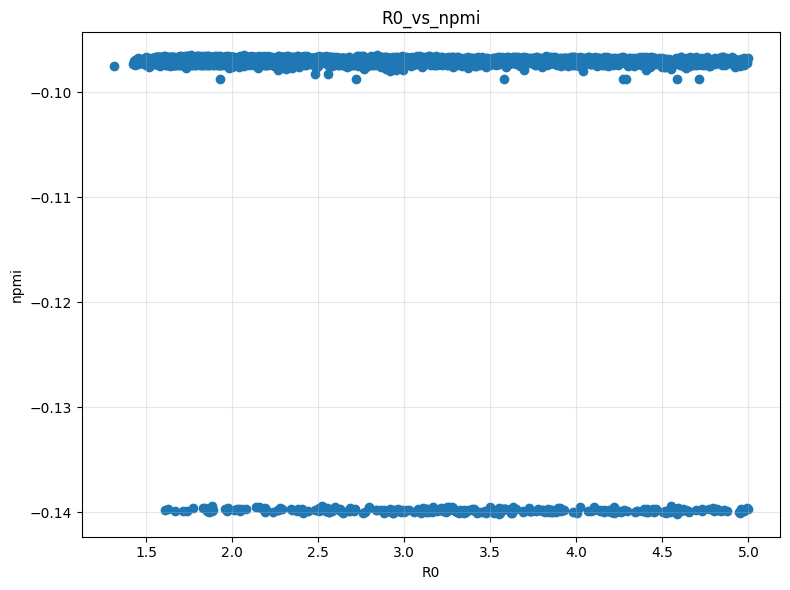

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_npmi.png


In [4]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    title='R0_vs_npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p0/'
)

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


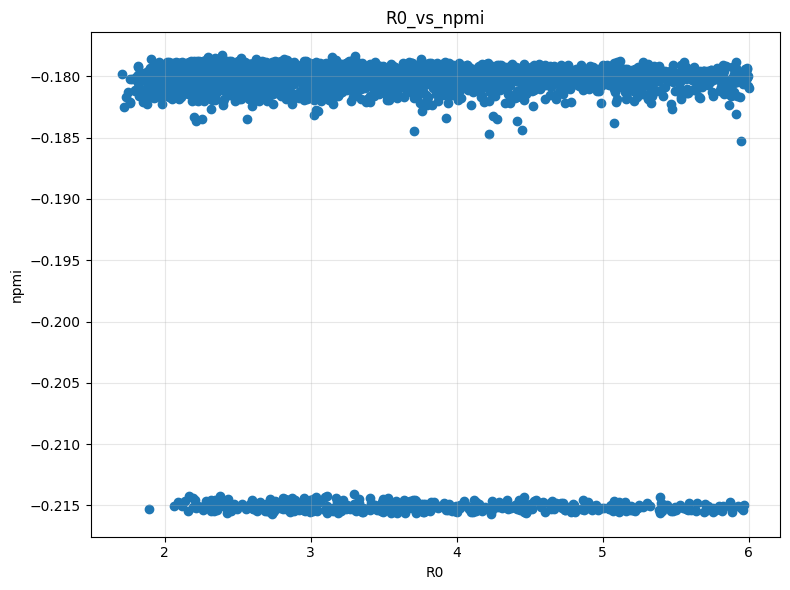

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_npmi.png


In [5]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    title='R0_vs_npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p5/'
)

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


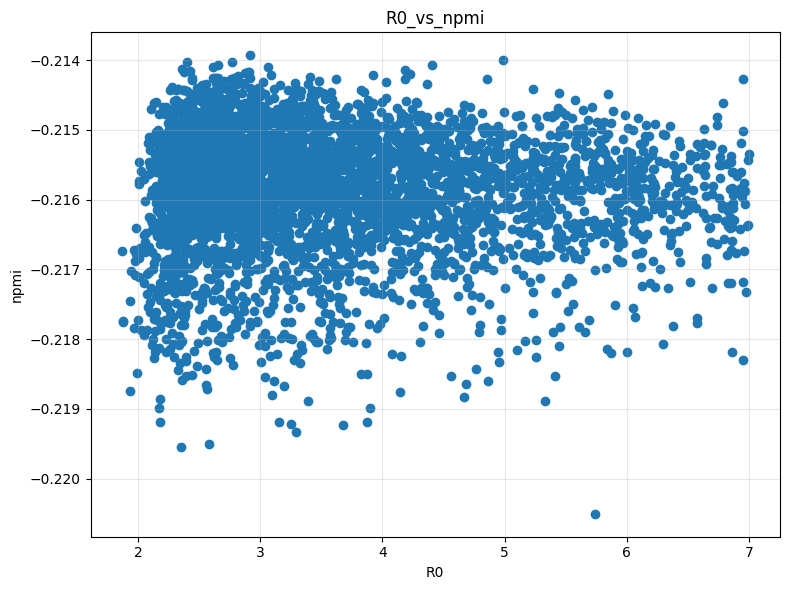

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_npmi.png


In [6]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p5/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


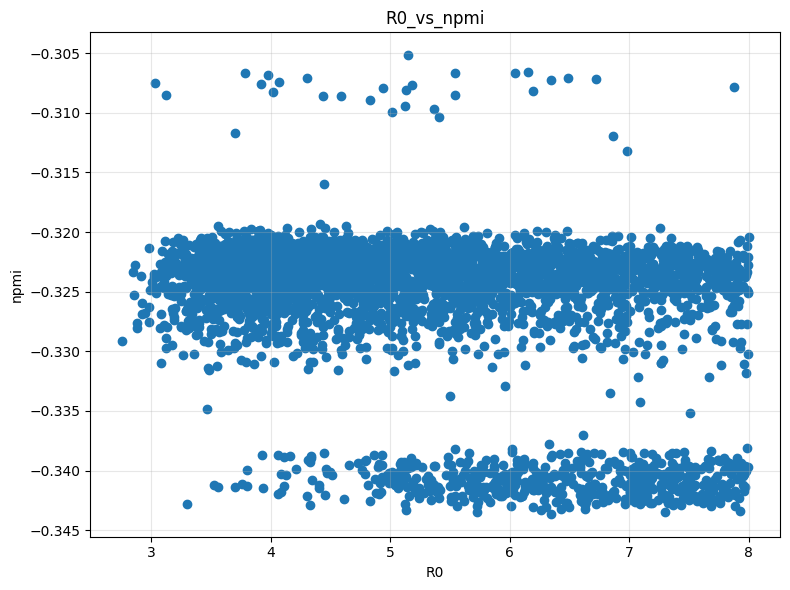

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p5/R0_vs_npmi.png


In [7]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    title='R0_vs_npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p5/'
)

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R05p0/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


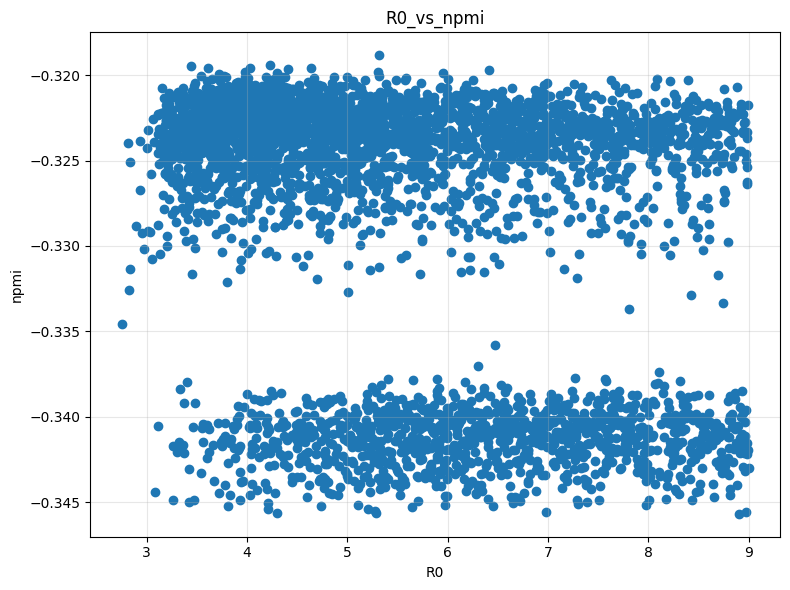

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R05p0/R0_vs_npmi.png


In [8]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R05p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R05p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R05p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=5.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R05p0/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R05p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R05p0.csv',
    title='R0_vs_npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R05p0/'
)